In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [7]:
DATA_PATH = '/data/hlobato/cryst'
os.listdir(DATA_PATH)

['lattice', 'random']

In [15]:
LATTICE_PATH = os.path.join(DATA_PATH, 'lattice')
LATTICE_FOLDERS = sorted([f for f in os.listdir(LATTICE_PATH) if ".data" not in f])
LATTICE_FOLDERS

['ipp_10',
 'ipp_20',
 'ipp_30',
 'ipp_40',
 'ipp_50',
 'ipp_60',
 'ipp_70',
 'ipp_80',
 'ipp_90']

In [16]:
RANDOM_PATH = os.path.join(DATA_PATH, 'random')
RANDOM_FOLDERS = sorted([f for f in os.listdir(RANDOM_PATH) if ".data" not in f])
RANDOM_FOLDERS

['ipp_10',
 'ipp_20',
 'ipp_30',
 'ipp_40',
 'ipp_50',
 'ipp_60',
 'ipp_70',
 'ipp_80',
 'ipp_90']

In [20]:
os.listdir(os.path.join(LATTICE_PATH, LATTICE_FOLDERS[0], 'in.def_7.4e-8'))

['equi.data',
 'in.def_7.4e-8',
 'data.6000000',
 'data.5000000',
 'data.4000000',
 'lattice_ipp_10_in.def_7.4e-8-5396679.out',
 'data.3000000',
 'lattice_ipp_10_in.def_7.4e-8-5396679.err',
 'data.1000000',
 'slurm_lammps',
 'data.7000000',
 'data.8000000',
 'log.lammps',
 'Tau.evol',
 '300K.data',
 'step_0_minimized.data',
 'ipp_10.data',
 '400K.data',
 'data.2000000']

In [26]:
os.path.dirname(os.path.join(LATTICE_PATH, LATTICE_FOLDERS[0], 'in.def_7.4e-8', 'Tau.evol'))

'/data/hlobato/cryst/lattice/ipp_10/in.def_7.4e-8'

Found 54 Tau.evol files


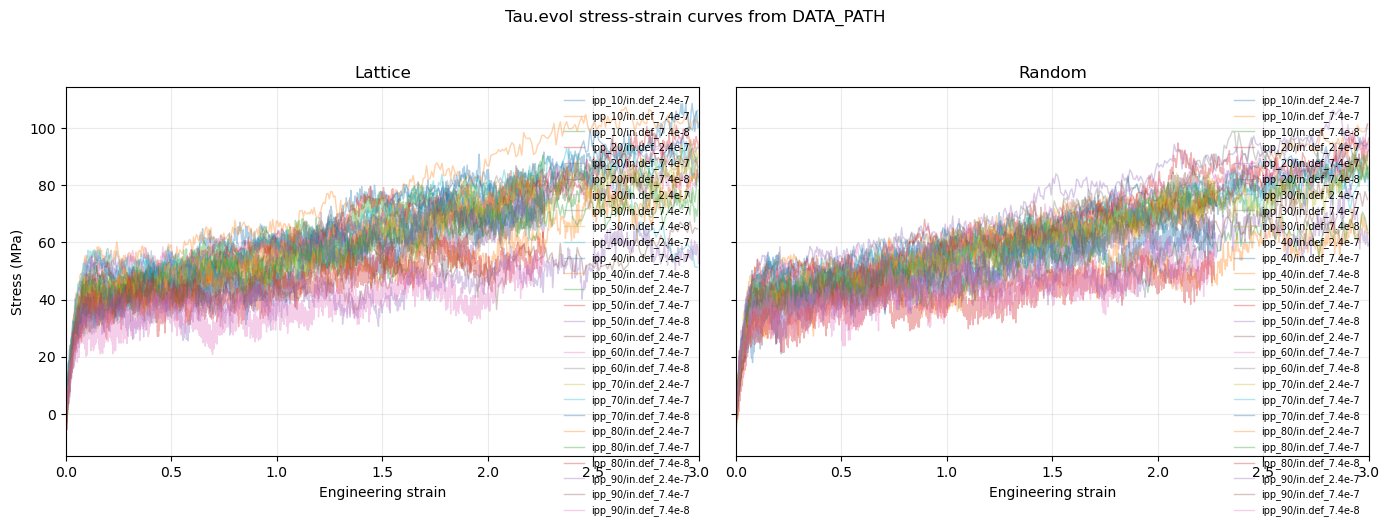

In [30]:
from pathlib import Path

MAX_STRAIN = 3.0


def load_tau_evol(path, max_strain=MAX_STRAIN):
    data = np.loadtxt(path, comments="#")
    if data.ndim == 1:
        data = data[None, :]

    strain = data[:, 1].astype(float) - 1.0
    stress = data[:, 3].astype(float) * 0.101325

    strain = np.insert(strain, 0, 0.0)
    stress = np.insert(stress, 0, 0.0)

    valid_mask = strain <= max_strain
    if np.any(valid_mask):
        last_valid_idx = np.where(valid_mask)[0][-1]
        strain = strain[: last_valid_idx + 1]
        stress = stress[: last_valid_idx + 1]
    else:
        strain = np.array([0.0], dtype=float)
        stress = np.array([0.0], dtype=float)

    return strain, stress


DATA_ROOT = Path(DATA_PATH)
tau_files = sorted(DATA_ROOT.rglob("Tau.evol"))
print(f"Found {len(tau_files)} Tau.evol files")

records = []
for path in tau_files:
    relative_parts = path.relative_to(DATA_ROOT).parts
    structure = relative_parts[0] if len(relative_parts) > 0 else "unknown"
    sample = relative_parts[1] if len(relative_parts) > 1 else path.parent.name
    rate_folder = relative_parts[2] if len(relative_parts) > 2 else path.parent.name
    strain, stress = load_tau_evol(path)
    records.append(
        {
            "path": str(path),
            "structure": structure,
            "sample": sample,
            "rate_folder": rate_folder,
            "n_points": len(strain),
            "max_strain": float(strain.max()) if len(strain) else 0.0,
            "max_stress": float(stress.max()) if len(stress) else 0.0,
        }
    )

curves_df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
structure_order = ["lattice", "random"]

for ax, structure in zip(axes, structure_order):
    structure_files = [path for path in tau_files if path.relative_to(DATA_ROOT).parts[0] == structure]
    for path in structure_files:
        strain, stress = load_tau_evol(path)
        parts = path.relative_to(DATA_ROOT).parts
        label = "/".join(parts[1:3]) if len(parts) >= 3 else path.stem
        ax.plot(strain, stress, alpha=0.35, lw=1, label=label)

    ax.set_title(structure.capitalize())
    ax.set_xlabel("Engineering strain")
    ax.set_xlim(0, MAX_STRAIN)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Stress (MPa)")

for ax in axes:
    if ax.lines:
        ax.legend(fontsize=7, frameon=False, loc="best")

fig.suptitle("Tau.evol stress-strain curves from DATA_PATH", y=1.02)
fig.tight_layout()
plt.show()

Loaded 54 curves from /home/hlobato/ipproject/curves_summary.json


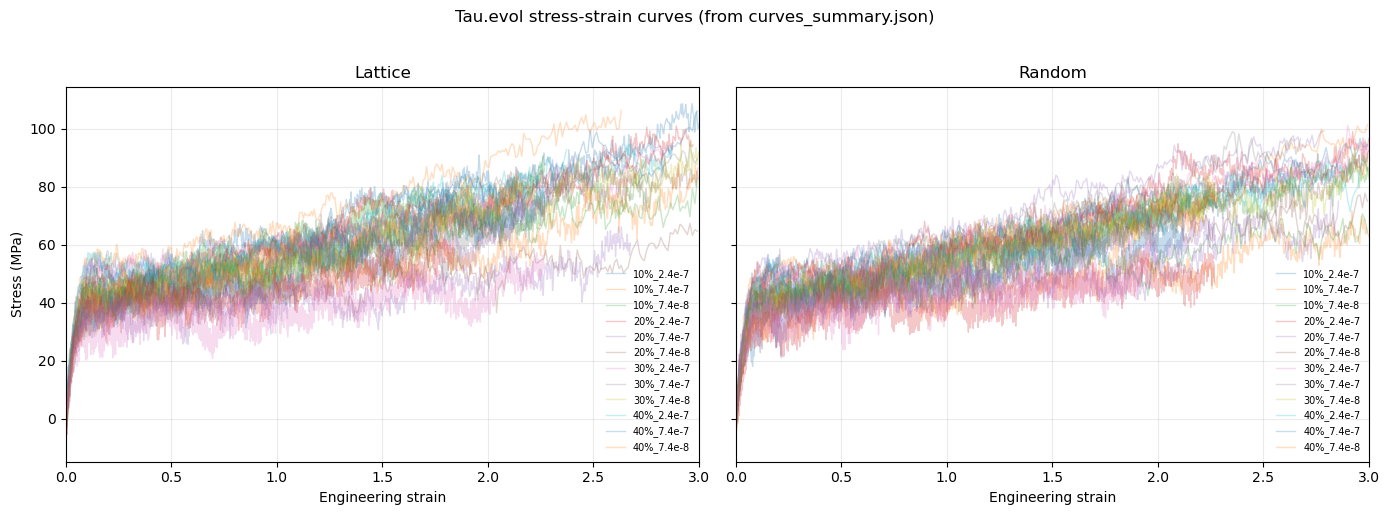

,curve_id,structure,crystallinity_pct,deformation_rate,n_cut,yield_stress,youngs_modulus
0,lattice_ipp_10_in.def_2.4e-7_Tau,lattice,10,2.400000e-07,1445,48.266604,681.401285
1,lattice_ipp_10_in.def_7.4e-7_Tau,lattice,10,7.400000e-07,437,56.219885,748.034886
2,lattice_ipp_10_in.def_7.4e-8_Tau,lattice,10,7.400000e-08,4001,41.134422,696.530883
3,lattice_ipp_20_in.def_2.4e-7_Tau,lattice,20,2.400000e-07,1438,45.080165,625.855136
4,lattice_ipp_20_in.def_7.4e-7_Tau,lattice,20,7.400000e-07,459,54.306519,711.483743
5,lattice_ipp_20_in.def_7.4e-8_Tau,lattice,20,7.400000e-08,3870,39.458832,681.526219
6,lattice_ipp_30_in.def_2.4e-7_Tau,lattice,30,2.400000e-07,1356,45.682644,797.839606
7,lattice_ipp_30_in.def_7.4e-7_Tau,lattice,30,7.400000e-07,469,54.875856,684.684955
8,lattice_ipp_30_in.def_7.4e-8_Tau,lattice,30,7.400000e-08,3629,42.659372,539.999418
9,lattice_ipp_40_in.def_2.4e-7_Tau,lattice,40,2.400000e-07,1411,43.561652,710.050219


In [32]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

json_path = Path('/home/hlobato/ipproject/curves_summary.json')
with json_path.open('r', encoding='utf-8') as f:
    payload = json.load(f)

records = list(payload.values())
print(f"Loaded {len(records)} curves from {json_path}")

# Group curves by structure
groups = {'lattice': [], 'random': []}
for r in records:
    struct = r.get('structure', 'unknown')
    groups.setdefault(struct, []).append(r)

# Plot overview: lattice vs random
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
for ax, struct in zip(axes, ['lattice', 'random']):
    curves = groups.get(struct, [])
    for rec in curves:
        strain = np.asarray(rec.get('strain', []), dtype=float)
        stress = np.asarray(rec.get('stress_mpa', []), dtype=float)
        if strain.size == 0 or stress.size == 0:
            continue
        xc = rec.get('crystallinity_pct', '')
        rate = rec.get('deformation_rate_label', '')
        label = f"{xc}%_{rate}"
        ax.plot(strain, stress, lw=1, alpha=0.25, label=label)

    ax.set_title(struct.capitalize())
    ax.set_xlabel('Engineering strain')
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel('Stress (MPa)')
# limit strain axis for readability
axes[0].set_xlim(0, 3.0)

# Reduce legend verbosity: show unique labels only
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # pick at most 12 unique labels to avoid clutter
    unique = {}
    out_handles, out_labels = [], []
    for h, l in zip(handles, labels):
        if l not in unique and len(out_labels) < 12:
            unique[l] = True
            out_handles.append(h)
            out_labels.append(l)
    if out_labels:
        ax.legend(out_handles, out_labels, fontsize=7, frameon=False, loc='best')

fig.suptitle('Tau.evol stress-strain curves (from curves_summary.json)', y=1.02)
fig.tight_layout()
plt.show()

# Optional: create a small DataFrame summary for quick inspection
try:
    import pandas as pd
    rows = []
    for r in records:
        rows.append({
            'curve_id': r.get('curve_id'),
            'structure': r.get('structure'),
            'crystallinity_pct': r.get('crystallinity_pct'),
            'deformation_rate': r.get('deformation_rate'),
            'n_cut': r.get('n_cut'),
            'yield_stress': r.get('yield_stress'),
            'youngs_modulus': r.get('youngs_modulus'),
        })
    df = pd.DataFrame(rows)
    display(df.sort_values(['structure','crystallinity_pct']).head(40))
except Exception:
    pass


raw points: 1445 smoothed points: 1445
raw head: [(np.float64(0.0), np.float64(0.0)), (np.float64(0.0007200000000000539), np.float64(3.3543438599999997)), (np.float64(0.0016799999999999038), np.float64(2.878460865)), (np.float64(0.0026399999999999757), np.float64(3.0162729974999998)), (np.float64(0.003609999999999891), np.float64(5.488977899999999))]
smoothed head: [(np.float64(0.0), np.float64(4.292349408429661)), (np.float64(0.0007200000000000539), np.float64(4.782713626038186)), (np.float64(0.0016799999999999038), np.float64(5.43530142814333)), (np.float64(0.0026399999999999757), np.float64(6.086453536432083)), (np.float64(0.003609999999999891), np.float64(6.74291194349177))]


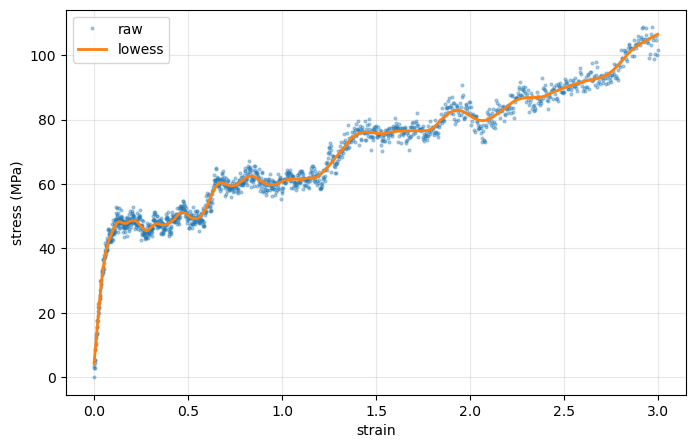

In [34]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np
import matplotlib.pyplot as plt

curve = first
x = np.asarray(curve.strain, dtype=float)
y = np.asarray(curve.stress_mpa, dtype=float)
sm = lowess(y, x, frac=0.05, return_sorted=True)
print('raw points:', len(x), 'smoothed points:', sm.shape[0])
print('raw head:', list(zip(x[:5], y[:5])))
print('smoothed head:', list(zip(sm[:5, 0], sm[:5, 1])))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, 'o', ms=2, alpha=0.35, label='raw')
ax.plot(sm[:, 0], sm[:, 1], '-', lw=2, label='lowess')
ax.set_xlabel('strain')
ax.set_ylabel('stress (MPa)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [35]:
from pathlib import Path
from plotting_function import plot_stress_curve_predictions
import numpy as np

one_key = next(iter(payload))
one_curve = {one_key: payload[one_key]}
raw = np.asarray(one_curve[one_key]['stress_mpa'], dtype=float)
sm = np.asarray(one_curve[one_key]['smoothed_stress_mpa'], dtype=float)
print('single curve key:', one_key)
print('raw len:', raw.size, 'smoothed len:', sm.size)
print('raw vs smoothed mean abs diff:', float(np.mean(np.abs(raw[:sm.size] - sm[:raw.size][:sm.size])) if raw.size and sm.size else 0.0))
out_path, axes = plot_stress_curve_predictions(one_curve, output_filename='single_curve_test_plot.png')
print('saved:', out_path)
print('axes type:', type(axes))

single curve key: lattice_ipp_10_in.def_2.4e-7_Tau
raw len: 1445 smoothed len: 1445
raw vs smoothed mean abs diff: 1.5720571287694756
saved: single_curve_test_plot.png
axes type: <class 'numpy.ndarray'>
